<h1>Imports</h1>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
import warnings
import shap
warnings.filterwarnings('ignore')

In [6]:
PATH_PROCESSED = '../../data/2_processed/processed.csv'

## Label Encoding e Preparação dos Dados

In [7]:
# Adicione seu DataFrame aqui manualmente
# Exemplo: df = pd.DataFrame({'feature1': [1, 2, 3], 'feature2': ['a', 'b', 'c'], 'target': [0, 1, 1]})

df = pd.read_csv(PATH_PROCESSED)

# Duplicate all rows
df = pd.DataFrame(
    np.repeat(df.values, 2, axis=0),
    columns=df.columns
)

# Optional: reset the index to have a clean, sequential index
df = df.reset_index(drop=True)

print("="*60)
print("📊 DATAFRAME ORIGINAL")
print("="*60)
print(df)
print(f"\nForma: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")

# ============================================
# LABEL ENCODING
# ============================================

print("\n" + "="*60)
print("🔤 LABEL ENCODING")
print("="*60)

# Copiar DataFrame para não modificar o original
df_encoded = df.copy()
label_encoders = {}

# Aplicar Label Encoding nas colunas categóricas
for column in df_encoded.columns:
    # Verificar se é coluna categórica/string
    if df_encoded[column].dtype in ['object', 'str'] or pd.api.types.is_string_dtype(df_encoded[column]):
        le = LabelEncoder()
        df_encoded[column] = le.fit_transform(df_encoded[column].astype(str))
        label_encoders[column] = le
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"\n✓ {column}:")
        print(f"  {mapping}")

print("\n" + "="*60)
print("📊 DATAFRAME APÓS ENCODING")
print("="*60)
print(df_encoded)
print(f"\nTipos de dados:\n{df_encoded.dtypes}")

📊 DATAFRAME ORIGINAL
                              ts conn_country  \
0      2020-10-23 19:52:08+00:00           BR   
1      2020-10-23 19:52:08+00:00           BR   
2      2020-10-23 19:55:36+00:00           BR   
3      2020-10-23 19:55:36+00:00           BR   
4      2020-10-23 19:55:36+00:00           BR   
...                          ...          ...   
15615  2026-01-21 13:52:42+00:00           BR   
15616  2026-01-21 17:27:15+00:00           BR   
15617  2026-01-21 17:27:15+00:00           BR   
15618  2026-01-22 20:17:04+00:00           BR   
15619  2026-01-22 20:17:04+00:00           BR   

            master_metadata_track_name master_metadata_album_album_name  \
0             I'm Gonna Show You Crazy         I'm Gonna Show You Crazy   
1             I'm Gonna Show You Crazy         I'm Gonna Show You Crazy   
2             I'm Gonna Show You Crazy         I'm Gonna Show You Crazy   
3             I'm Gonna Show You Crazy         I'm Gonna Show You Crazy   
4             I

## Divisão em Treino e Teste

In [ ]:
# Separar features (X) e target (y)
# Altere 'target' se o nome da coluna for diferente
X = df_encoded.drop('next_track', axis=1)
y = df_encoded['next_track']

print("="*60)
print("📋 SEPARAÇÃO DE FEATURES E TARGET")
print("="*60)
print("Features (X):")
print(X.head())
print(f"\nTarget (y):")
print(y.head())
print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

# Dividir em treino (80%) e teste (20%)
# Se o dataset é muito pequeno, não usa stratify
n_samples = len(y)
use_stratify = len(np.unique(y)) < n_samples * 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "="*60)
print("🔀 DIVISÃO TREINO/TESTE (80/20)")
print("="*60)
print(f"Treino - X: {X_train.shape}, y: {y_train.shape}")
print(f"Teste  - X: {X_test.shape}, y: {y_test.shape}")
print(f"\nDistribuição no Treino:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nDistribuição no Teste:\n{pd.Series(y_test).value_counts().sort_index()}")

📋 SEPARAÇÃO DE FEATURES E TARGET
Features (X):
   ts  conn_country  master_metadata_track_name  \
0   0             0                         419   
1   0             0                         419   
2   1             0                         419   
3   1             0                         419   
4   1             0                         419   

   master_metadata_album_album_name  reason_start  reason_end  shuffle  \
0                               265             2           1        0   
1                               265             2           1        0   
2                               265             2           5        0   
3                               265             2           5        0   
4                               265             2           5        0   

   skipped  offline  incognito_mode  ...  speechiness  tempo  valence  \
0        0        0               0  ...          314    954      193   
1        0        0               0  ...          314  

## Treinamento do Modelo Gradient Boost

In [9]:
# Verificar se é um problema de classificação ou regressão
# Se y tem valores contínuos => Regressão
# Se y tem valores discretos/categorias => Classificação

unique_values = np.unique(y)
is_classification = len(unique_values) < 20  # Heurística simples

print(f"Valores únicos de y: {unique_values}")
print(f"Tipo de problema detectado: {'Classificação' if is_classification else 'Regressão'}\n")

# Criar e treinar o modelo
if is_classification:
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        verbose=0
    )
    model_type = "Classificação"
else:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        verbose=0
    )
    model_type = "Regressão"

print(f"Treinando modelo de {model_type}...")
model.fit(X_train, y_train)
print("✓ Modelo treinado com sucesso!")

Valores únicos de y: [   0    1    2 ... 1537 1538 1539]
Tipo de problema detectado: Regressão

Treinando modelo de Regressão...


✓ Modelo treinado com sucesso!


## XAI

Generating Summary Plot...


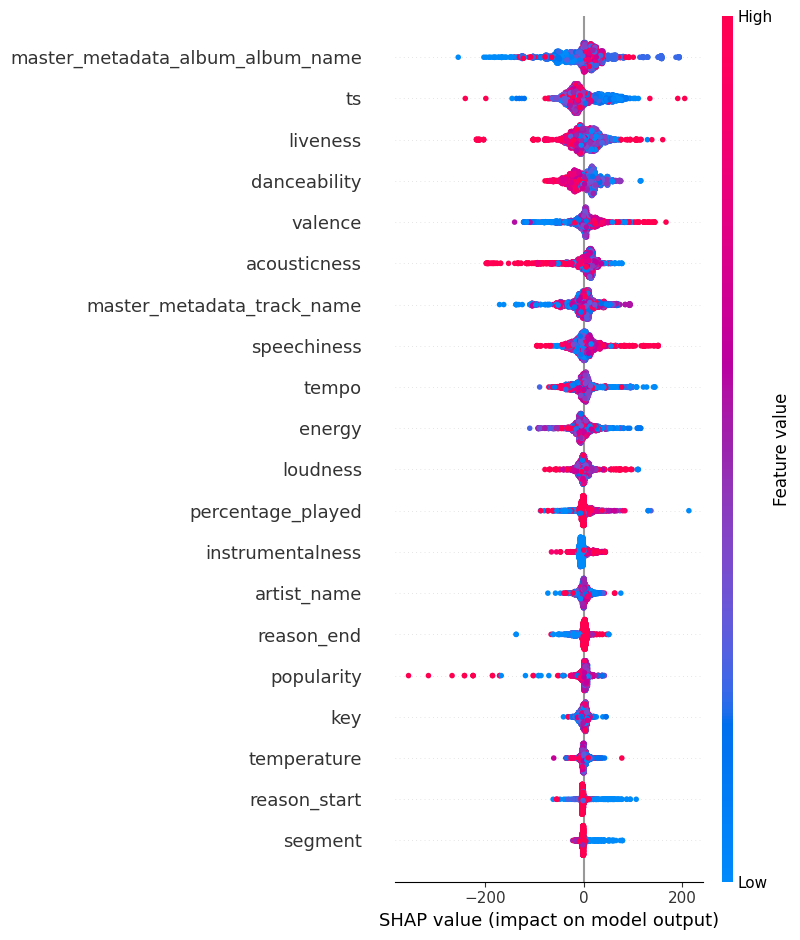

Generating Waterfall Plot for the first test instance...


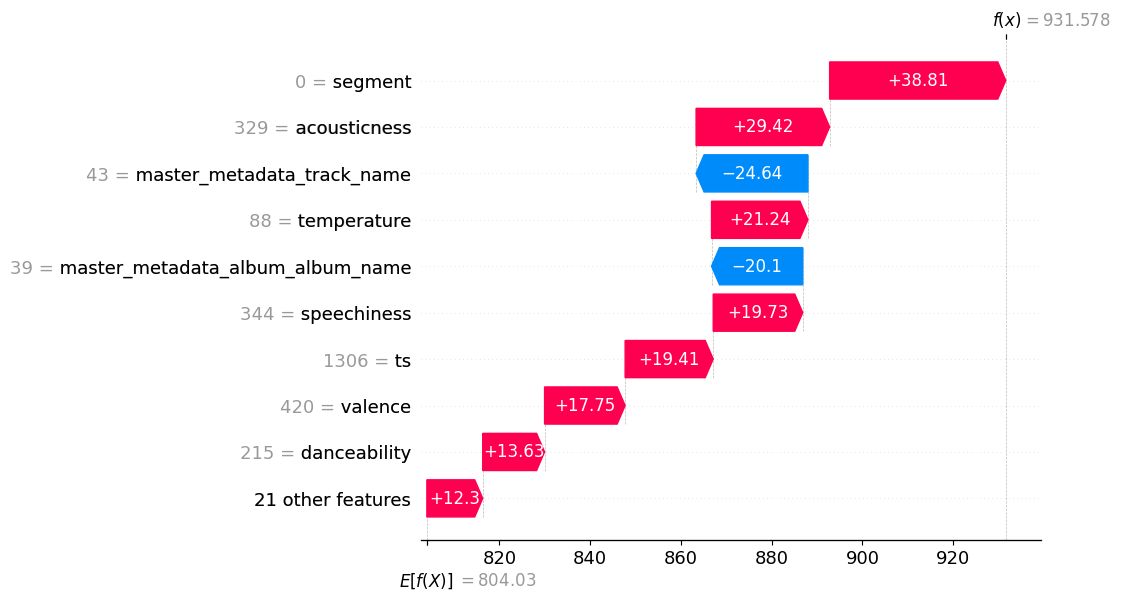

In [10]:

# 1. Initialize the SHAP explainer with your best model
# Use TreeExplainer specifically for Gradient Boosting, which is highly efficient
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values for your test set
# This converts the model's complex logic into feature-level contributions
shap_values = explainer(X_test)

# 3. Global Interpretability (Understand what makes a song generally "recommended")
print("Generating Summary Plot...")
shap.summary_plot(shap_values, X_test)

# 4. Local Interpretability (Explain why ONE specific song was recommended)
# This shows the user the exact features that led to the prediction
print("Generating Waterfall Plot for the first test instance...")
shap.plots.waterfall(shap_values[0])

## Avaliação do Modelo

In [11]:
# Fazer predições
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("=" * 60)
print(f"AVALIAÇÃO DO MODELO - {model_type}")
print("=" * 60)

if is_classification:
    # Métricas para Classificação
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"\n📊 Acurácia (Accuracy):")
    print(f"   Treino: {train_accuracy:.4f}")
    print(f"   Teste:  {test_accuracy:.4f}")
    
    print(f"\n📋 Relatório de Classificação (Conjunto de Teste):")
    print(classification_report(y_test, y_test_pred))
    
else:
    # Métricas para Regressão
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\n📊 Mean Squared Error (MSE):")
    print(f"   Treino: {train_mse:.4f}")
    print(f"   Teste:  {test_mse:.4f}")
    
    print(f"\n📊 Root Mean Squared Error (RMSE):")
    print(f"   Treino: {train_rmse:.4f}")
    print(f"   Teste:  {test_rmse:.4f}")
    
    print(f"\n📊 Mean Absolute Error (MAE):")
    print(f"   Treino: {train_mae:.4f}")
    print(f"   Teste:  {test_mae:.4f}")
    
    print(f"\n📊 R² Score:")
    print(f"   Treino: {train_r2:.4f}")
    print(f"   Teste:  {test_r2:.4f}")

print(f"\n📈 Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.to_string(index=False))

AVALIAÇÃO DO MODELO - Regressão

📊 Mean Squared Error (MSE):
   Treino: 130638.4856
   Teste:  149546.6122

📊 Root Mean Squared Error (RMSE):
   Treino: 361.4395
   Teste:  386.7126

📊 Mean Absolute Error (MAE):
   Treino: 301.7141
   Teste:  322.5953

📊 R² Score:
   Treino: 0.3384
   Teste:  0.2418

📈 Feature Importance:
                         feature  importance
master_metadata_album_album_name    0.116345
                              ts    0.087673
      master_metadata_track_name    0.077852
                        liveness    0.071851
                          energy    0.071804
                    acousticness    0.071788
                         valence    0.058293
                     speechiness    0.057197
                           tempo    0.056404
                    danceability    0.056288
                        loudness    0.040785
               percentage_played    0.036867
                      popularity    0.032327
                     artist_name    0.031492
 